In [9]:
# ==============================
# LOAD DATASET (NO MOVE NEEDED)
# ==============================
!pip install -q kagglehub

import kagglehub
import os

# download dataset
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Dataset path:", path)

# IMPORTANT: actual folder is inside this path
DATASET_PATH = os.path.join(path, "brain_tumor_dataset")

print("Folders:", os.listdir(DATASET_PATH))

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset path: /kaggle/input/brain-mri-images-for-brain-tumor-detection
Folders: ['no', 'yes']


TensorFlow Version: 2.19.0
Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset Path: /kaggle/input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset
Classes: ['no', 'yes']
Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.6946 - loss: 0.6778 - val_accuracy: 0.7400 - val_loss: 0.5451
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7882 - loss: 0.4891 - val_accuracy: 0.6600 - val_loss: 0.6143
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7488 - loss: 0.4811 - val_accuracy: 0.7600 - val_loss: 0.6227
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.7241 - loss: 0.5599 - val_accuracy: 0.7400 - val_loss: 0.5802
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.8325 - loss: 0.4415 - val_accuracy: 0.7800 - val_loss: 0.5585
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.8325 - loss: 0.4144 - val_accuracy: 0.7400 - val_loss: 0.5438
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8621 - loss: 0.3925 - val_accuracy: 0.7600 - val_loss: 0.5412
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8966 - loss: 0.3173 - val_accuracy: 0.7800 - val_loss: 0.4

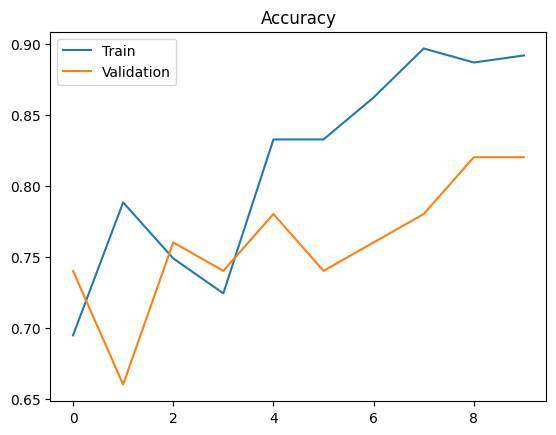

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
Tumor Detected
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


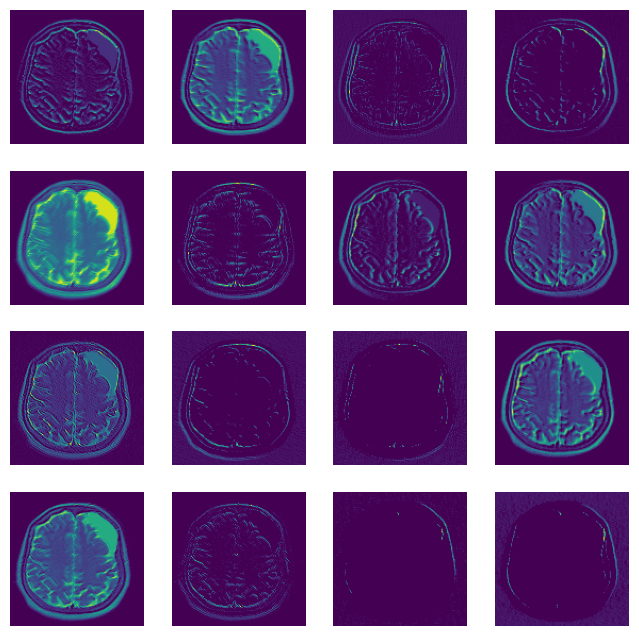

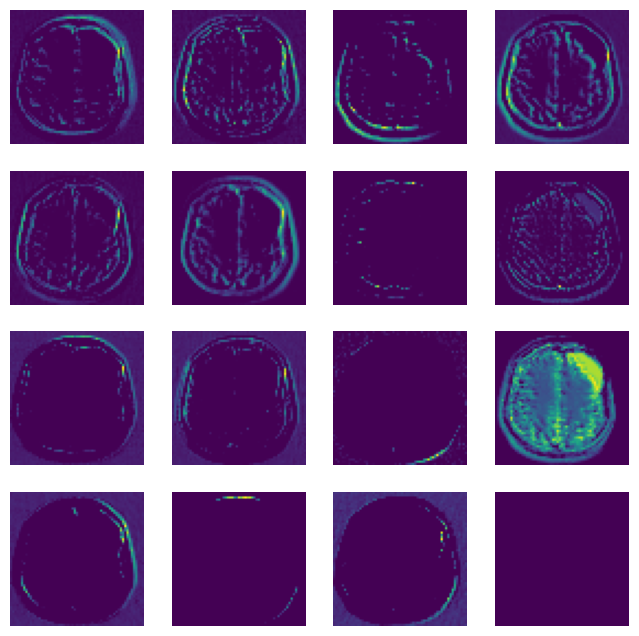

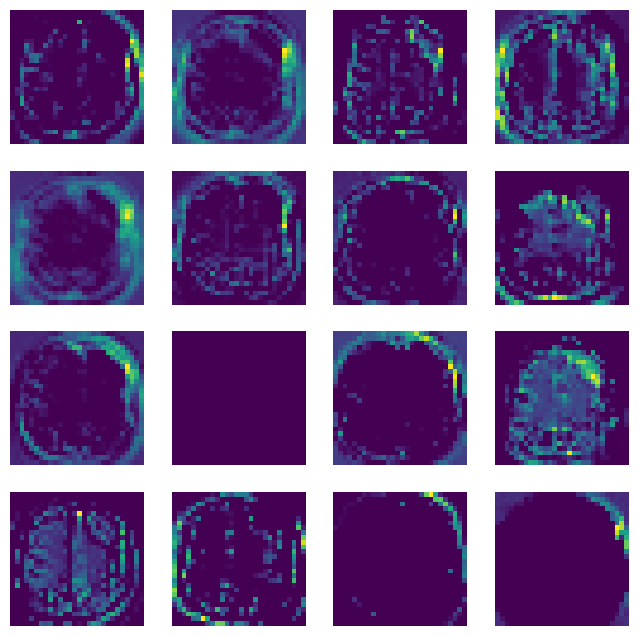

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


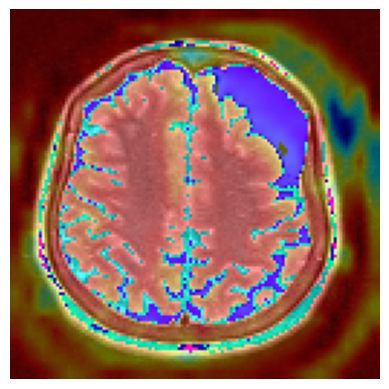

In [15]:
# ==============================
# 1. Install + Import Libraries
# ==============================
!pip install -q tensorflow opencv-python matplotlib kagglehub

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import kagglehub

from tensorflow.keras import layers, models, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version:", tf.__version__)

# ==============================
# 2. Load Dataset (FIXED PATH)
# ==============================
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

# ✅ IMPORTANT FIX (removes extra class issue)
DATASET_PATH = os.path.join(path, "brain_tumor_dataset")

print("Dataset Path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))

# ==============================
# 3. Data Preprocessing
# ==============================
IMG_SIZE = 128
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# ==============================
# 4. Build CNN Model (FIXED)
# ==============================
model = models.Sequential([
    Input(shape=(128,128,3)),   # ✅ FIXED

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', name="last_conv"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# ==============================
# 5. Compile
# ==============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==============================
# 6. Train
# ==============================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ==============================
# 7. Accuracy Graph
# ==============================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# ==============================
# 8. Save Model
# ==============================
model.save("brain_tumor_model.keras")

# ==============================
# 9. Prediction
# ==============================
sample_img = os.path.join(DATASET_PATH, "yes", os.listdir(DATASET_PATH + "/yes")[0])

def predict_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.reshape(img, (1,128,128,3))

    pred = model.predict(img)

    if pred > 0.5:
        print("Tumor Detected")
    else:
        print("No Tumor")

predict_image(sample_img)

# ==============================
# 10. FILTER VISUALIZATION (FIXED)
# ==============================
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, layers.Conv2D)]
activation_model = models.Model(inputs=model.inputs, outputs=layer_outputs)

img = cv2.imread(sample_img)
img = cv2.resize(img, (128,128))
img = img / 255.0
img = np.reshape(img, (1,128,128,3))

activations = activation_model.predict(img)

for layer_activation in activations:
    plt.figure(figsize=(8,8))
    for i in range(min(layer_activation.shape[-1], 16)):
        plt.subplot(4,4,i+1)
        plt.imshow(layer_activation[0,:,:,i])
        plt.axis('off')
    plt.show()

# Force model to build (VERY IMPORTANT FIX)
_ = model.predict(np.zeros((1,128,128,3)))
# ==============================
# ==============================
# ==============================
# 11. GRAD-CAM (ULTIMATE FIX)
# ==============================

# 🔥 Force-build model graph properly
dummy = tf.random.normal((1,128,128,3))
_ = model(dummy)

def get_gradcam(model, img_array, layer_name):
    # Use model.inputs instead of model.input (IMPORTANT)
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.layers[-1].output]
    )

    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# ==============================
# APPLY GRAD-CAM
# ==============================

img = cv2.imread(sample_img)
img = cv2.resize(img, (128,128))
img_array = np.expand_dims(img/255.0, axis=0)

heatmap = get_gradcam(model, img_array, "last_conv")

heatmap = cv2.resize(heatmap, (128,128))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.imshow(superimposed_img.astype("uint8"))
plt.axis('off')
plt.show()